# $\sigma_{PS}$ condensate vs mass, all Nf (gsq=8, nt128 L1)

Reads `h0/condensate/etadag_xi` from the massive Real-$m$ disc data
(`data_Nf{nf}_..._mRe{m}..._vmRe{m}.../corr_ylm_disc_tb2_nhits1/`).
Convention = per-mass notebook's $\sigma_{PS}$ cell: $\mathrm{dens}=\mathrm{etadag\_xi}/(N_t\cdot 4\pi)$,
$\sigma_{PS}=\mathrm{dens}+\overline{\mathrm{dens}}$; **contact-subtracted $+2$**
(`condensate_contact_massive_claude.md` Sec 10) = SSB order parameter.
Config-jackknife (1 hit/config).  Masses $m_F=0.2,0.1,0.05,0.01$; Nf=2,4,6.


In [1]:
import h5py, numpy as np, glob, math
import matplotlib.pyplot as plt

Nt = 128; sumA = 4.0*math.pi; norm = Nt*sumA
MASS_DIR = ['0.200000', '0.100000', '0.050000', '0.010000']   # dir string (sea = valence mass)
MASS = np.array([0.2, 0.1, 0.05, 0.01])                       # numeric m_F for the x-axis
NFS = [2, 4, 6]
NFMARK = ['o', 's', '^']                                      # colorblind: distinct marker per Nf

def esn(nf, m): return f'data_Nf{nf}_gsq8.000000at0.200000nu01.000000mRe{m}mIm0.000000nt128L1_vmRe{m}vmIm0.000000/'
def disc_files(nf, m): return sorted(glob.glob(esn(nf, m)+'corr_ylm_disc_tb2_nhits1/corr.*.h0.h5'))

def cond_cfg(files):
    out = []
    for fn in files:
        with h5py.File(fn, 'r') as f:
            out.append(f['h0/condensate/etadag_xi/real'][0] + 1j*f['h0/condensate/etadag_xi/imag'][0])
    return np.array(out)

def jackknife(samp):                  # delete-1 over config axis -> mean, err_re, err_im
    H = samp.shape[0]
    jk = (samp.sum(0)-samp)/(H-1)
    mean = samp.mean(0)
    ere = np.sqrt(np.maximum((H-1)*np.mean((jk.real-mean.real)**2, 0), 0.0))
    eim = np.sqrt(np.maximum((H-1)*np.mean((jk.imag-mean.imag)**2, 0), 0.0))
    return mean, ere, eim

# sigma_PS per (Nf, mass): raw + contact-subtracted (+2), config-jackknifed.  SIG[nf] = (raw_m, raw_e, sub_m, sub_e)
SIG = {}
for nf in NFS:
    rm = []; re = []; sm = []; se = []
    for md_ in MASS_DIR:
        df = disc_files(nf, md_)
        etx = cond_cfg(df)
        dens = etx/norm
        sig = dens + np.conj(dens)
        m0, e0, _ = jackknife(sig)
        m2, e2, _ = jackknife(sig + 2.0)
        rm.append(m0.real); re.append(e0); sm.append(m2.real); se.append(e2)
    SIG[nf] = (np.array(rm), np.array(re), np.array(sm), np.array(se))
    print(f'Nf={nf}: loaded {len(disc_files(nf, MASS_DIR[0]))} cfg/mass')


Nf=2: loaded 140 cfg/mass
Nf=4: loaded 140 cfg/mass
Nf=6: loaded 140 cfg/mass


In [2]:
# Table: sigma_PS raw and contact-subtracted (+2), all Nf x all masses.
print(f"{'m_F':>5} {'Nf':>3} {'sigma_PS raw':>22} {'contact-sub (+2)':>22}")
for j, m in enumerate(MASS):
    for nf in NFS:
        rm, re, sm, se = SIG[nf]
        print(f"{m:>5} {nf:>3}   {rm[j]:>+10.5f} +/- {re[j]:.1e}    {sm[j]:>+10.5f} +/- {se[j]:.1e}")
    print()


  m_F  Nf           sigma_PS raw       contact-sub (+2)
  0.2   2     -1.84230 +/- 1.2e-05      +0.15770 +/- 1.2e-05
  0.2   4     -1.84222 +/- 1.1e-05      +0.15778 +/- 1.1e-05
  0.2   6     -1.84217 +/- 1.1e-05      +0.15783 +/- 1.1e-05

  0.1   2     -1.91864 +/- 8.1e-06      +0.08136 +/- 8.1e-06
  0.1   4     -1.91862 +/- 6.6e-06      +0.08138 +/- 6.6e-06
  0.1   6     -1.91859 +/- 7.6e-06      +0.08141 +/- 7.6e-06

 0.05   2     -1.95868 +/- 3.8e-06      +0.04132 +/- 3.8e-06
 0.05   4     -1.95867 +/- 3.5e-06      +0.04133 +/- 3.5e-06
 0.05   6     -1.95865 +/- 3.5e-06      +0.04135 +/- 3.5e-06

 0.01   2     -1.99163 +/- 7.8e-07      +0.00837 +/- 7.8e-07
 0.01   4     -1.99163 +/- 7.2e-07      +0.00837 +/- 7.2e-07
 0.01   6     -1.99163 +/- 8.3e-07      +0.00837 +/- 8.3e-07



Nf=2: contact-sub sigma_PS = +0.7841*m_F + (+0.00162)   [linear fit; intercept = m->0 condensate]
Nf=4: contact-sub sigma_PS = +0.7845*m_F + (+0.00161)   [linear fit; intercept = m->0 condensate]
Nf=6: contact-sub sigma_PS = +0.7847*m_F + (+0.00162)   [linear fit; intercept = m->0 condensate]


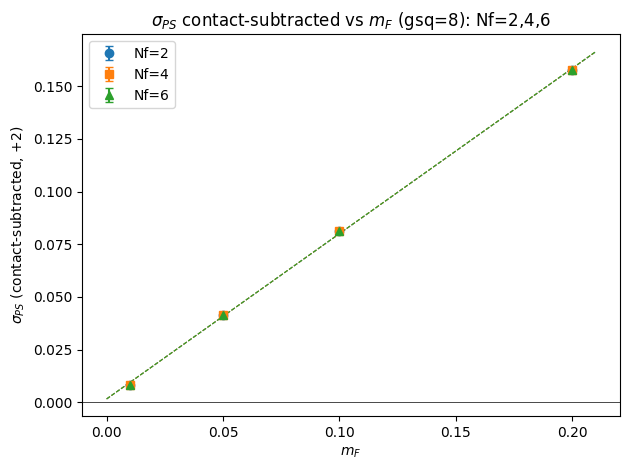

In [3]:
# Contact-subtracted sigma_PS vs m_F, Nf=2,4,6, with a linear chiral fit (intercept = chiral limit).
# Fit printed BEFORE the plot.
for nf in NFS:
    rm, re, sm, se = SIG[nf]
    slope, icpt = np.polyfit(MASS, sm, 1)
    print(f'Nf={nf}: contact-sub sigma_PS = {slope:+.4f}*m_F + ({icpt:+.5f})   [linear fit; intercept = m->0 condensate]')

fig, ax = plt.subplots()
mg = np.linspace(0.0, MASS.max()*1.05, 50)
for i, nf in enumerate(NFS):
    rm, re, sm, se = SIG[nf]
    slope, icpt = np.polyfit(MASS, sm, 1)
    ax.errorbar(MASS, sm, yerr=se, marker=NFMARK[i], ls='none', capsize=3, label=f'Nf={nf}')
    ax.plot(mg, slope*mg + icpt, ls='--', lw=0.8, color=ax.lines[-1].get_color())
ax.axhline(0.0, color='k', lw=0.5)
ax.set_xlabel(r'$m_F$'); ax.set_ylabel(r'$\sigma_{PS}$ (contact-subtracted, $+2$)')
ax.set_title(r'$\sigma_{PS}$ contact-subtracted vs $m_F$ (gsq=8): Nf=2,4,6')
ax.legend(); plt.tight_layout()


In [5]:
# # Raw sigma_PS vs m_F, Nf=2,4,6 (before the +2 contact subtraction).
# fig, ax = plt.subplots()
# for i, nf in enumerate(NFS):
#     rm, re, sm, se = SIG[nf]
#     ax.errorbar(MASS, rm, yerr=re, marker=NFMARK[i], ls='none', capsize=3, label=f'Nf={nf}')
# ax.axhline(-2.0, color='k', lw=0.5, ls=':')
# ax.set_xlabel(r'$m_F$'); ax.set_ylabel(r'$\sigma_{PS}$ (raw)')
# ax.set_title(r'$\sigma_{PS}$ raw vs $m_F$ (gsq=8): Nf=2,4,6  (contact term $\approx-2$)')
# ax.legend(); plt.tight_layout()
